**Analysis of Electoral Trends and Voter Behavior in 
Kerala Legislative Assembly Elections**

Analyzes Kerala legislative assembly election data 
to identify voting patterns and party performance. the data will be 
used to examine votes received by parties across years, 
voter turnout by constituency, candidate demographics,
 and winning margins. 
visualizations will be created to understand electoral 
trends and voter behavior in Kerala.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("https://docs.google.com/spreadsheets/d/13Vg7zWlKvStaAtpucK4U3VppL9VIDqdi/export?format=csv")

This dataset contains kerala assembly election results
each row represents one candidate contesting in one constituency in a given election year
the dataset captures candidate level electoral performance across constituencies and years

In [3]:

df=df[df["Year "].isin([2011,2016,2021])]

By election results are excluded to maintain consistency.  
Only general election years (2011, 2016, 2021) are used for analysis.

In [4]:
df.shape

(3411, 16)

In [5]:
df.describe()

,Year,Age,Position,Assembly Constituency Candidates,Total Electors in Constituency,Total Votes Obtained,Total Valid Votes,Vote Share Percentage,Margin,Margin Percentage,Turn out Percentage
count,3411.000000,3131.000000,3411.000000,3411.000000,3411.000000,3411.000000,3411.000000,3411.000000,3411.000000,3411.000000,3411.000000
mean,2016.184697,48.532098,4.862504,8.009675,185360.382293,17158.646438,140231.680446,12.313128,8259.365875,5.940035,75.734348
std,3.889366,11.604168,2.833840,2.175219,20464.905914,25938.910598,16471.966829,18.489014,14472.627649,10.411670,4.655643
min,2011.000000,24.000000,1.000000,3.000000,132780.000000,37.000000,97297.000000,0.020000,0.000000,0.000000,60.350000
25%,2011.000000,40.000000,3.000000,6.000000,170245.000000,375.000000,128427.000000,0.270000,44.000000,0.030000,72.470000
50%,2016.000000,48.000000,5.000000,8.000000,184917.000000,953.000000,139894.000000,0.700000,297.000000,0.210000,75.970000
75%,2021.000000,57.000000,7.000000,9.000000,199692.000000,34698.500000,151911.000000,24.770000,10009.500000,7.095000,78.900000
max,2021.000000,92.000000,18.000000,17.000000,247274.000000,96129.000000,193822.000000,63.750000,70671.000000,45.130000,87.720000


In [6]:
df.columns

Index(['Year ', 'Assembly Constituency Name', 'Assmebly Constituency Type ',
       'Candidate Name ', 'Sex ', 'Age', 'Party', 'Position',
       'Assembly Constituency Candidates', 'Total Electors in Constituency',
       'Total Votes Obtained', 'Total Valid Votes ', 'Vote Share Percentage',
       'Margin', 'Margin Percentage', 'Turn out Percentage '],
      dtype='str')

In [7]:
df.head(5)

,Year,Assembly Constituency Name,Assmebly Constituency Type,Candidate Name,Sex,Age,Party,Position,Assembly Constituency Candidates,Total Electors in Constituency,Total Votes Obtained,Total Valid Votes,Vote Share Percentage,Margin,Margin Percentage,Turn out Percentage
0,2011,Adoor,SC,Chittayam Gopakumar,MALE,45.0,CPI,1,8,194014,63501,135057,47.02,607,0.45,69.61
1,2011,Adoor,SC,Pandalam Sudhakaran,MALE,55.0,INC,2,8,194014,62894,135057,46.57,56684,41.97,69.61
2,2011,Adoor,SC,K K Sasi,MALE,43.0,BJP,3,8,194014,6210,135057,4.60,5216,3.86,69.61
3,2011,Adoor,SC,Olikkulangara Surendran,MALE,34.0,IND,4,8,194014,994,135057,0.74,475,0.35,69.61
4,2011,Adoor,SC,Kodumon Ramachandran,MALE,61.0,BSP,5,8,194014,519,135057,0.38,57,0.04,69.61


In [8]:
df.tail()

,Year,Assembly Constituency Name,Assmebly Constituency Type,Candidate Name,Sex,Age,Party,Position,Assembly Constituency Candidates,Total Electors in Constituency,Total Votes Obtained,Total Valid Votes,Vote Share Percentage,Margin,Margin Percentage,Turn out Percentage
3457,2021,Wandoor,SC,A P Anilkumar,MALE,56.0,INC,1,4,230696,87415,169931,51.44,15563,9.16,73.66
3458,2021,Wandoor,SC,Midhuna P,FEMALE,28.0,CPM,2,4,230696,71852,169931,42.28,64795,38.13,73.66
3459,2021,Wandoor,SC,Dr P C Vijayan,MALE,63.0,BJP,3,4,230696,7057,169931,4.15,4114,2.42,73.66
3460,2021,Wandoor,SC,Krishnan C,MALE,58.0,Welfare Party of India,4,4,230696,2943,169931,1.73,2279,1.34,73.66
3461,2021,Wandoor,SC,Nota,NaN,NaN,NOTA,5,4,230696,664,169931,0.39,0,0.00,73.66


In [9]:
df.isnull().sum()

Year                                  0
Assembly Constituency Name            0
Assmebly Constituency Type            0
Candidate Name                        0
Sex                                 280
Age                                 280
Party                                 0
Position                              0
Assembly Constituency Candidates      0
Total Electors in Constituency        0
Total Votes Obtained                  0
Total Valid Votes                     0
Vote Share Percentage                 0
Margin                                0
Margin Percentage                     0
Turn out Percentage                   0
dtype: int64

In [10]:
df.columns = df.columns.str.strip()
df["Sex"]=df["Sex"].fillna(df["Sex"].mode()[0])

The column names contained unnecessary spaces, so they were cleaned using string stripping.
Missing values in the Sex column were filled using the mode.

In [11]:
df["Age"]=df["Age"].fillna(df["Age"].median()).astype(int)

Null values in the Age column were replaced with the median.
The values were then converted to integers for consistency.

In [12]:
df.isnull().sum()

Year                                0
Assembly Constituency Name          0
Assmebly Constituency Type          0
Candidate Name                      0
Sex                                 0
Age                                 0
Party                               0
Position                            0
Assembly Constituency Candidates    0
Total Electors in Constituency      0
Total Votes Obtained                0
Total Valid Votes                   0
Vote Share Percentage               0
Margin                              0
Margin Percentage                   0
Turn out Percentage                 0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

Year                                  int64
Assembly Constituency Name              str
Assmebly Constituency Type              str
Candidate Name                          str
Sex                                     str
Age                                   int64
Party                                   str
Position                              int64
Assembly Constituency Candidates      int64
Total Electors in Constituency        int64
Total Votes Obtained                  int64
Total Valid Votes                     int64
Vote Share Percentage               float64
Margin                                int64
Margin Percentage                   float64
Turn out Percentage                 float64
dtype: object

In [15]:
df["Sex"].unique()

<StringArray>
['MALE', 'FEMALE', 'THIRD']
Length: 3, dtype: str

In [16]:
df["Sex"].value_counts()

Sex
MALE      3112
FEMALE     298
THIRD        1
Name: count, dtype: int64

In [17]:
df["Assembly Constituency Name"].unique()

<StringArray>
[        'Adoor',     'Alappuzha',       'Alathur',         'Aluva',
   'Ambalapuzha',      'Angamaly',      'Aranmula',         'Aroor',
    'Aruvikkara',      'Attingal',
 ...
      'Vadakara',        'Vaikom',   'Vallikkunnu',   'Vamanapuram',
       'Varkala', 'Vattiyoorkavu',       'Vengara',         'Vypen',
 'Wadakkanchery',       'Wandoor']
Length: 140, dtype: str

In [18]:
df["Party"]=df["Party"].str.upper() #standardized text
df["Party"].unique()

<StringArray>
[                                                 'CPI',
                                                  'INC',
                                                  'BJP',
                                                  'IND',
                                                  'BSP',
                                                 'SDPI',
                                                 'NOTA',
                                                  'PDP',
                                                 'SUCI',
 'ANNA DEMOCRATIC HUMAN RIGHTS MOVEMENT PARTY OF INDIA',
                                                  'CPM',
                                'BAHUJAN DRAVIDA PARTY',
                                               'KEC(M)',
                                                  'SHS',
                                                 'WPOI',
                               'WELFARE PARTY OF INDIA',
             'MARXIST COMMUNIST PARTY OF INDIA(UNITED)',
                 

In [19]:
df["Turn out Percentage"].describe()

count    3411.000000
mean       75.734348
std         4.655643
min        60.350000
25%        72.470000
50%        75.970000
75%        78.900000
max        87.720000
Name: Turn out Percentage, dtype: float64

In [20]:
df.groupby("Year")["Turn out Percentage"].mean()

Year
2011    75.175139
2016    77.549859
2021    74.006691
Name: Turn out Percentage, dtype: float64

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")

C:\Users\HP\AppData\Local\Temp\ipykernel_11376\2361687861.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




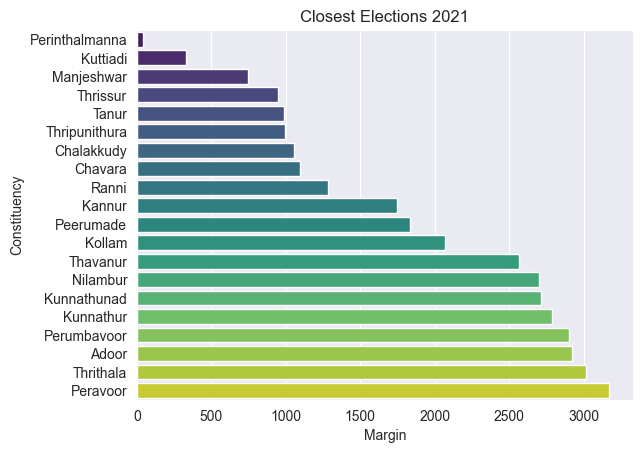

In [26]:
winner = df[df["Position"] == 1]
close = winner[winner["Year"]==2021].sort_values("Margin").head(20)

sns.barplot(data=close, x="Margin", y="Assembly Constituency Name",palette="viridis")

plt.title("Closest Elections 2021")
plt.xlabel("Margin")
plt.ylabel("Constituency")

plt.show()

these constituencies represent the most competitive seats in the 2021 election

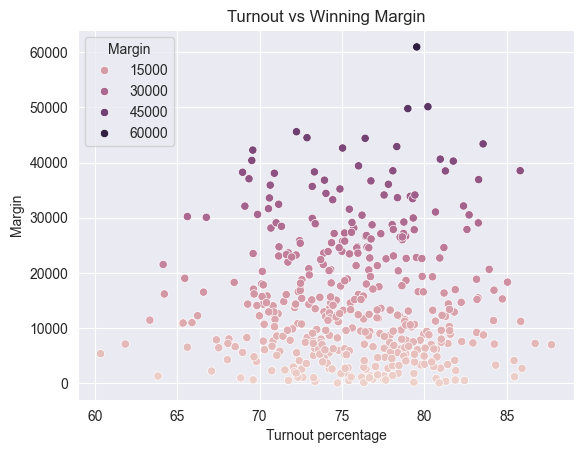

In [ ]:
sns.scatterplot(data=winner,x="Turn out Percentage", y="Margin", hue="Margin")
plt.xlabel("Turnout percentage")
plt.ylabel("Margin")
plt.title("Turnout vs Winning Margin")
plt.show()

shows relationship between voter turnout and winning margin

each point represents a constituency

in this chart there is no strong relationship between turnout and winning margin, high turnout doesnt guarantee bigger victory

C:\Users\HP\AppData\Local\Temp\ipykernel_13524\2077868646.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




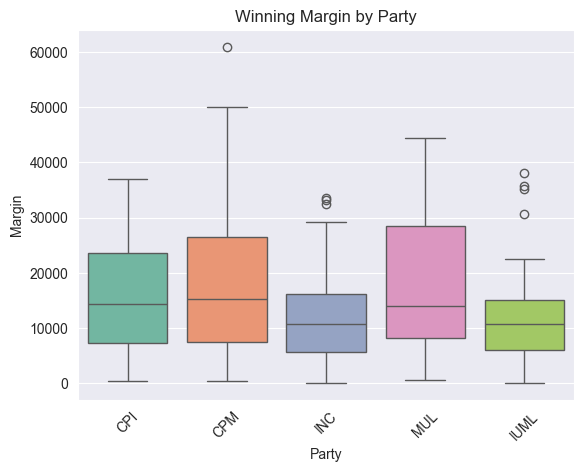

In [ ]:
top_parties = winner["Party"].value_counts().head(5).index
filtered = winner[winner["Party"].isin(top_parties)]

sns.boxplot(data=filtered, x="Party", y="Margin",palette="Set2")

plt.xticks(rotation=45)
plt.xlabel("Party")
plt.ylabel("Margin")
plt.title("Winning Margin by Party")

plt.show()

shows how winning margins vary across major parties

wider spread indicates inconsistent performance

higher median suggests stronger victories

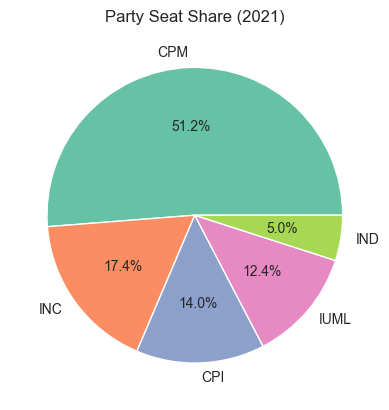

In [ ]:
data = winner[winner["Year"] == 2021]["Party"].value_counts().head(5)

plt.pie(data.values, labels=data.index, autopct="%1.1f%%",colors=sns.color_palette("Set2"))

plt.title("Party Seat Share (2021)")

plt.show()

shows proportion of seats won by top parties in 2021

larger slices indicate stronger dominance

helps visualize how seats are distributed among parties

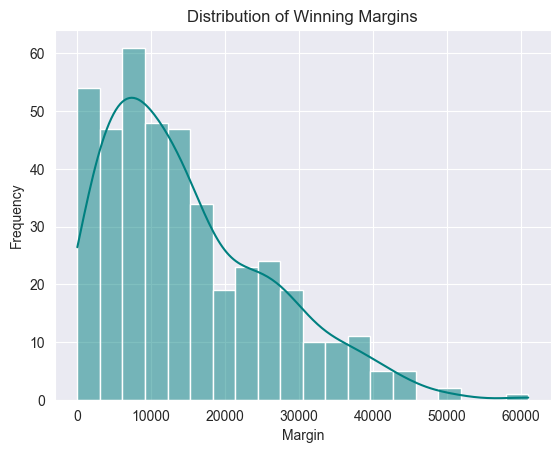

In [ ]:
sns.histplot(winner["Margin"], bins=20, kde=True,color="teal")

plt.xlabel("Margin")
plt.ylabel("Frequency")
plt.title("Distribution of Winning Margins")

plt.show()

shows how winning margins are distributed across constituencies
most seats have moderate margins


C:\Users\HP\AppData\Local\Temp\ipykernel_13524\1243326530.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




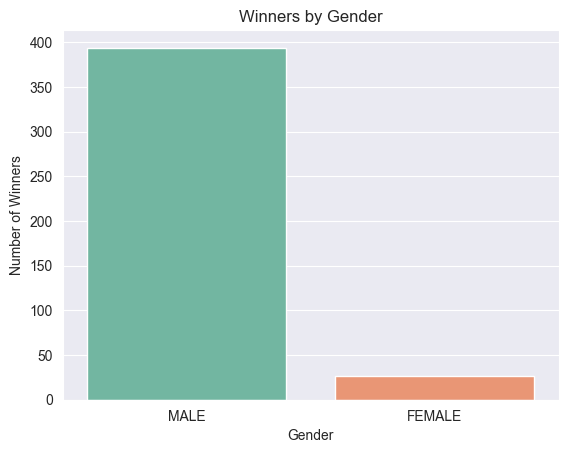

In [ ]:
sns.countplot(data=winner, x="Sex",palette="Set2")

plt.xlabel("Gender")
plt.ylabel("Number of Winners")
plt.title("Winners by Gender")

plt.show()

shows number of male and female winners

highlights gender imbalance in election results

significant difference indicates unequal representation

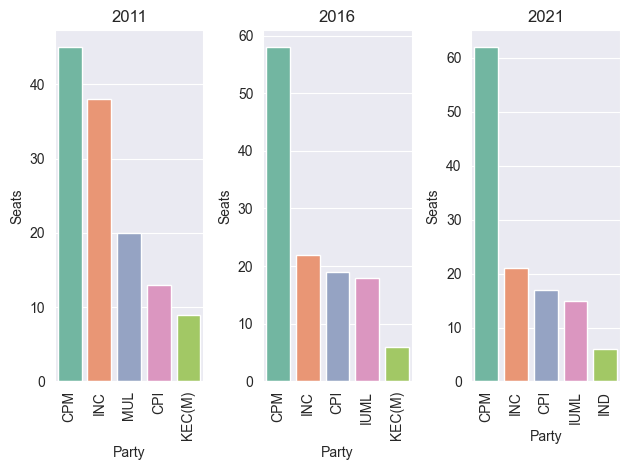

In [ ]:
years = [2011, 2016, 2021]

fig,axes = plt.subplots(1, 3)

for i, year in enumerate(years):
    data = winner[winner["Year"] == year]["Party"].value_counts().head(5)

    sns.barplot(x=data.index, y=data.values,hue=data.index, ax=axes[i],palette="Set2",legend=False)
    
    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Party")
    axes[i].set_ylabel("Seats")
    axes[i].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

compares top parties across years

shows how party dominance changes over time

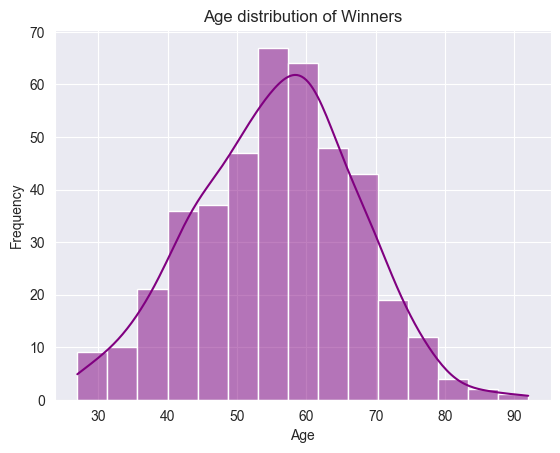

In [ ]:
sns.histplot(winner["Age"],bins=15, kde=True,color="purple")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age distribution of Winners")
plt.show()

shows how age of winning candidates is distributed

helps identify common age range of winners

indicates whether younger or older candidates dominate

In [24]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default="vscode"
candidate = df.groupby(["Year","Assembly Constituency Name"]).size()
count=candidate.value_counts().sort_index().reset_index()
count.columns=["Candidates","Constituencies"]

fig=px.bar(count,x="Constituencies",y="Candidates",orientation="h",title="Candidates per Constituency")
fig.show()

shows how many candidates typically contest in a constituency

higher values indicate more competition

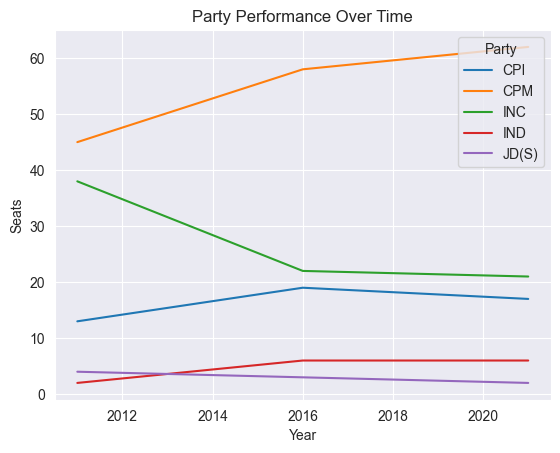

In [ ]:


trend = winners.groupby(
    ["Year", "Party"]
).size().reset_index(name="Seats")
top=trend["Party"].value_counts().nlargest(5).index

sns.lineplot(data=trend[trend["Party"].isin(top)], x="Year", y="Seats",hue="Party")
plt.title("Party Performance Over Time")
plt.show()

shows how each party’s seat count changes over time, revealing who is gaining or losing power and whether the state is stable or competitive


## INSIGHTS



## 1. elections are mostly competitive

most wins fall in low margin ranges

no party is overwhelmingly dominant everywhere
many constituencies are decided by small differences

---

## 2. competition is not consistent

close margin counts vary by year

some elections are tighter than others
political intensity changes over time

---

## 3. turnout does not decide results

no strong relation between turnout and margin

more voters ≠ closer election
outcomes depend on voter distribution, not volume

---

## 4. party dominance is uneven

some parties win with large margins, others don’t

strong parties have concentrated support

weaker ones rely on narrow wins

---

## 5. power shifts across years

seat counts change between elections

voters are switching between parties

no permanent control across all constituencies
---

## 6. state is politically competitive

top party position is not fixed

multiple parties remain relevant
elections are not one-sided

---

## 7. key battleground constituencies exist

some areas consistently have very small margins

these are swing regions
they decide overall election outcomes

---

## 8. representation is skewed

majority winners are male

gender imbalance is clear
low female political participation

---

## 9. politics favors middle age

most winners fall in mid-age range

experience and network matter more than youth

---

## 10. margins alone are misleading

large seat count doesn’t always mean strong support

parties can win many seats with small margins
real dominance needs vote share analysis

---

## final blunt summary

* elections are competitive but uneven
* power shifts happen, but not uniformly
* outcomes depend on distribution, not just turnout